<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/b9/f01qnt9138b6dw8s0z7fjlz40000gn/T/ipykernel_34473/4168548989.py:34: SyntaxWarning: invalid escape sequence '\s'
  file1 = pd.read_csv("./phaseShifts_3S1-3D1np.txt", sep='\s+',  header=None)


Reading Benchmark.ini...
pot = 213
channel = 0
j = 1
np1 = 25
np2 = 15
p1 = 1.5
p2 = 10.0
p3 = 50
mapp = 'tanh'
c = 8.0
k0, k  0.0015528428742757842 [1.10728035e-02 5.82697912e-02 1.42895142e-01 2.64512751e-01
 4.22541843e-01 6.16346490e-01 8.45326468e-01 1.10901722e+00
 1.40719625e+00 1.73999388e+00 2.10800839e+00 2.51242742e+00
 2.95516025e+00 3.43898821e+00 3.96774327e+00 4.54652868e+00
 5.18200066e+00 5.88273648e+00 6.65972473e+00 7.52702807e+00
 8.50269183e+00 9.61000681e+00 1.08792906e+01 1.23504423e+01
 1.40766735e+01 1.61300759e+01 1.86101248e+01 2.16570320e+01
 2.54733727e+01 3.03604104e+01 3.67817385e+01 4.54805079e+01
 5.77087521e+01 7.57103941e+01 1.03837697e+02 1.51464289e+02
 2.41954309e+02 4.47880866e+02 1.09833927e+03 5.77992736e+03
 1.55284287e-03]
t00, t20, t02, t22  (0.3062201765287928-0.0010883335606532497j) (6.609377612197385e-07-2.349031194480188e-09j) (6.609377612197378e-07-2.3490311944801887e-09j) (4.362252666291498e-12-5.0700885760040564e-15j)
 elaspsed time : 

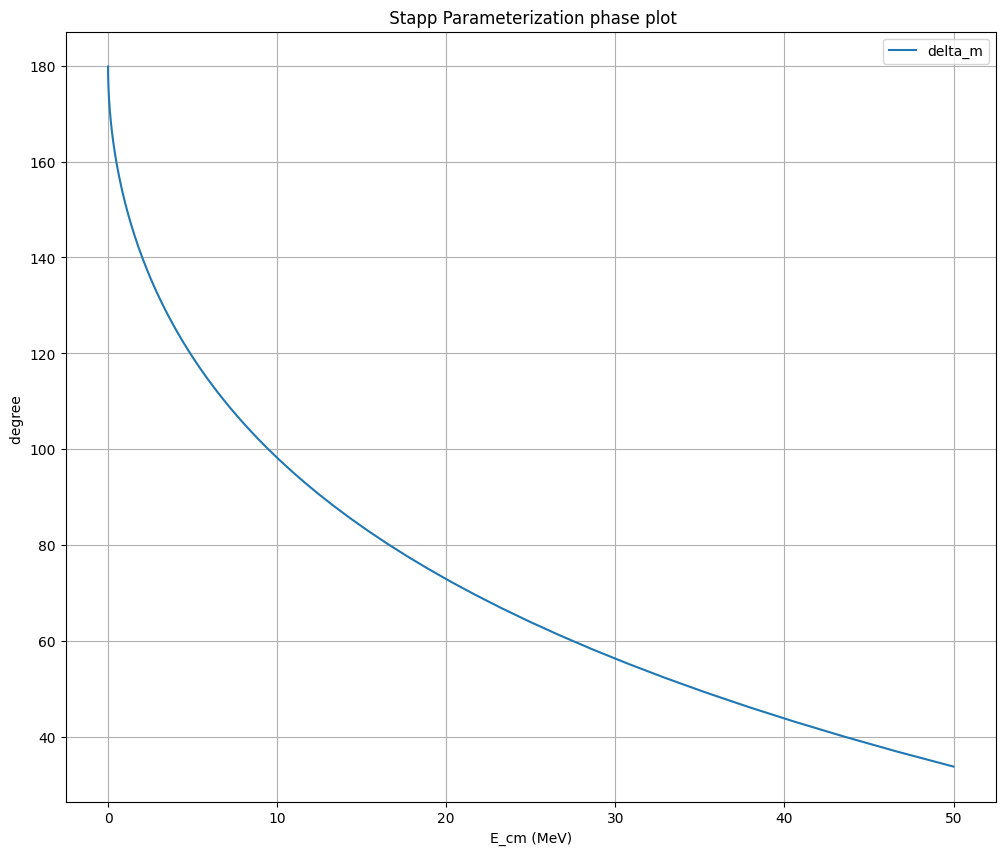

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 0.9999999999999999, 1.0, 1.0, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 0.9999999999999999, 1.0, 1.0, 0.9999999999999999, 1.0, 0.9999999999999998, 1.0, 0.9999999999999998, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 0.9999999999999998, 1.0, 0.9999999999999999, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 0.9999999999999998, 0.9999999999999999, 0.9999999999999999, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 1.0, 0.9999999999999999, 1.0, 1.0, 1.0, 0.9999999999999999, 0.9999999999999998, 1.0000000000000002, 1.0, 0.9999999999999999, 0.9999999999999998, 0.99

In [14]:
#import Main_Tmatrix as MTm
import multiple_E_couple_phase as MECP
import Coupled_phases as CP
import numpy as np
import matplotlib.pyplot as plt

from Config import Config

config = Config('Benchmark.ini')
config.print_info()

Ecms =np.logspace(-4,2,200)
mapp = config.mapp
np1 = config.np1
np2 = config.np2
p1 = config.p1
p2 = config.p2
p3 = config.p3
c = config.c
pot = config.pot
channel = config.channel
number_of_points = np1+np2
N = number_of_points
s = 1
j = 1

phase_convention = CP.Stapp_parameterization_phase

eta_p, eta_m, epsi_l, delta_p, delta_m = MECP.call_coupled_tmatrix(N, mapp, p1, p2, p3, np1, np2, c, Ecms, phase_convention, s, j, pot, channel)


import pandas as pd

file1 = pd.read_csv("./phaseShifts_3S1-3D1np.txt", sep='\s+',  header=None)

x1 = file1.iloc[:, 0]
y = file1.iloc[:, 1]

# plotting phases vs Ecm from above calculations
fig, axs = plt.subplots(1, 1, figsize=(12, 10))
#axs.plot(x1, y, label="Dr. Drischler's phases")
E_lab = 0.5*Ecms
axs.plot(E_lab, delta_m, label='delta_m')
axs.set_xlabel("E_cm (MeV)")
axs.set_ylabel("degree ")
if phase_convention == CP.Stapp_parameterization_phase:
    axs.set_title(f" Stapp Parameterization phase plot")
else:
    axs.set_title(f" Blatt Biedenharn phase plot")
axs.legend()
plt.grid()
plt.show()


print(eta_p)

print()

print(eta_m)


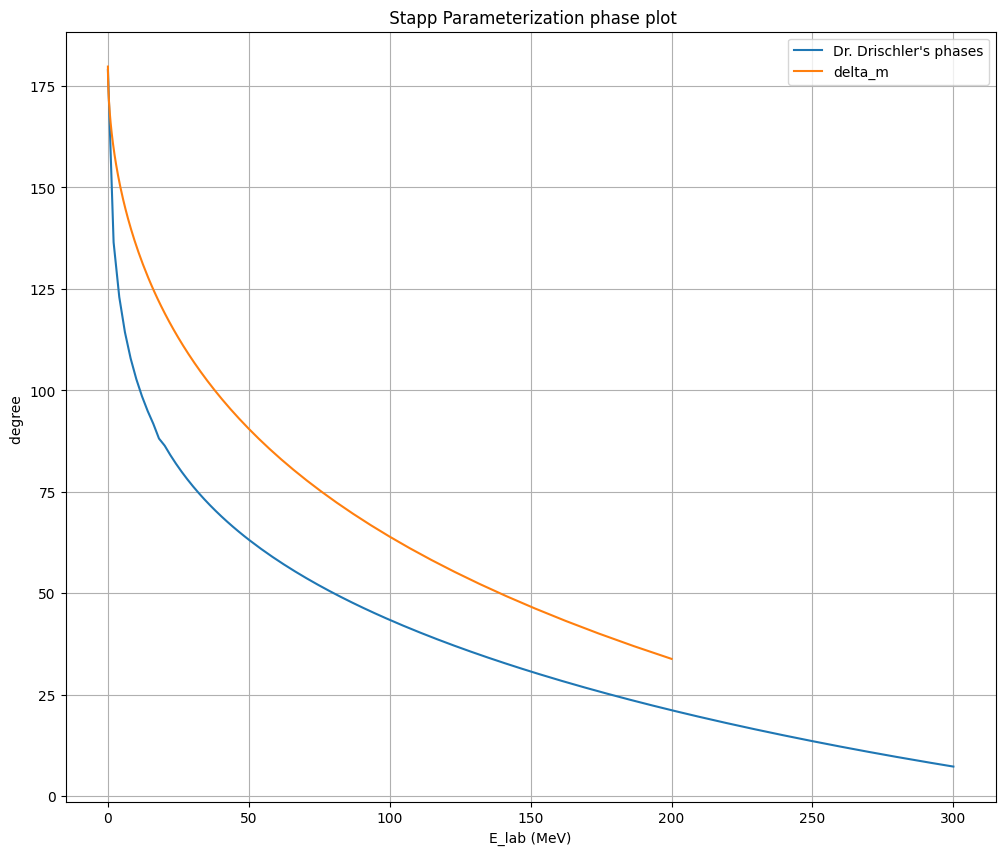

In [15]:
# plotting phases vs Ecm from above calculations
fig, axs = plt.subplots(1, 1, figsize=(12, 10))
x1 = file1.iloc[:, 0]
y1 = file1.iloc[:, 1]
y2 = file1.iloc[:, 2]
y3 = file1.iloc[:, 3]
axs.plot(x1, y1, label="Dr. Drischler's phases")
E_lab = 2*Ecms
axs.plot(E_lab, delta_m, label='delta_m')
axs.set_xlabel("E_lab (MeV)")
axs.set_ylabel("degree ")


if phase_convention == CP.Stapp_parameterization_phase:
    axs.set_title(f" Stapp Parameterization phase plot")
else:
    axs.set_title(f" Blatt Biedenharn phase plot")
axs.legend()


plt.grid()
plt.show()

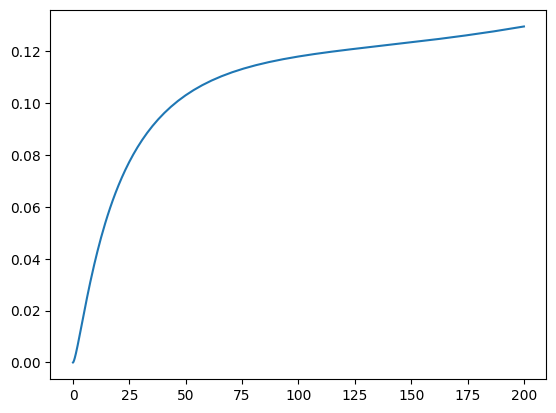

In [13]:
plt.plot(E_lab, epsi_l)
plt.show()

In [ ]:
file2 = pd.read_csv("./NN_3S1.txt", sep='\s+',  header=None)

NN_ener = file1.iloc[:, 0]
NN_phase = file1.iloc[:, 1]

fig, axs = plt.subplots(1, 1, figsize=(12, 10))
axs.plot(NN_ener, NN_phase, label="NN 3S1 phases")
axs.plot(x1, y1, label="Dr. Drischler's phases")
E_lab = 2*Ecms
#axs.plot(E_lab, delta_p, label='delta_p')
axs.set_xlabel("E_lab (MeV)")
axs.set_ylabel("degree ")
axs.legend()
plt.show()


<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/var/folders/b9/f01qnt9138b6dw8s0z7fjlz40000gn/T/ipykernel_34473/4037931037.py:15: SyntaxWarning: invalid escape sequence '\s'
  file1 = pd.read_csv("./VNN_N2LO_fulllocal_R0_1.0_SLLJT_00001_lambda_50.00_Np_125_np.dat", sep='\s+',  header=None)


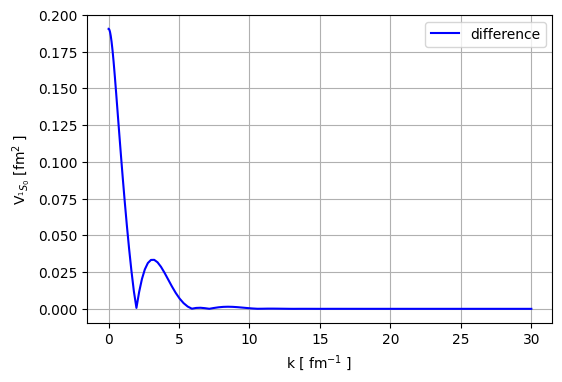

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chiralPot

# two_mu = 938.9182


# Defining constants
h_barc = 197.327  # Mev fm
h_barc_sq = h_barc*h_barc
two_mu = (939.56563+938.27205)/h_barc  # fm^-1

# Opening the csv files generated from both python and c++. And, then plotting the data and difference in the data
file1 = pd.read_csv("./VNN_N2LO_fulllocal_R0_1.0_SLLJT_00001_lambda_50.00_Np_125_np.dat", sep='\s+',  header=None)
table = pd.DataFrame(file1)
inv_two_mu = 1/two_mu
m = 2
index_lower = 125*m 
index_upper = 125*(m+1) 
y1 = file1.iloc[index_lower:index_upper, 2]*inv_two_mu
y = np.array(y1)

x1 = np.array(file1.iloc[index_lower:index_upper, 1])
V = np.zeros(len(y))
diff = np.zeros(len(y))
ki = file1.iloc[index_lower+1, 0]
l = 0
ll = 0
s = 0
j = 0
pot = 213
channel = 0
for i in range(len(y)):
    V[i] = chiralPot.V0(ki, x1[i], pot, s, l, ll, j, channel) * h_barc_sq
    diff[i] = abs(V[i]-y[i])

# for plotting the fig side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))


#ax.plot(x1, y, color='green', label="Dr. Drischler's" )
ax.plot(x1, diff, color='blue', label='difference')
ax.set_xlabel(r'k [ fm$^{-1}$ ] ')
ax.set_ylabel(r'V$_{^1S_0}$ [fm$^2$ ]')
ax.legend()
ax.grid(True)


plt.show()
